In [1]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools


universe = [
    # Semiconductors / equipment / EDA
    "NVDA","AMD","AVGO","MU","AMAT","LRCX","KLAC","ADI","TXN","INTC",
    "QCOM","MRVL","NXPI","MCHP","ON","MPWR","TER","ENTG","SWKS","LSCC",
    "RMBS","QRVO","COHR","SYNA","IPGP","ALGM","CRUS","DIOD","FORM","POWI",
    "AEIS","SITM","MKSI","AMKR","ASML","TSM","SNPS","CDNS","STM",

    # Software / cloud / data / dev tools
    "MSFT","ORCL","CRM","NOW","ADBE","INTU","ADSK","DDOG","MDB","SNOW",
    "HUBS","SHOP","TEAM","GTLB","ESTC","PATH","CFLT","DOCN","AI","WK",
    "BOX","DBX","NTAP","WDAY","FICO","ROP","U","ZI","TWLO","PAYC",
    "VEEV","ANSS","MANH","BILL","PCOR","DT","APP","PLTR",

    # Cybersecurity / networking / infrastructure software
    "CRWD","PANW","FTNT","NET","ZS","OKTA","CHKP","FFIV","AKAM","CSCO",
    "ANET","GEN","QLYS","VRNS","TENB","RDWR","ATEN","NTCT","CVLT","RPD",
    "LDOS","BAH","IBM","JNPR","CIEN"
]

In [55]:
PCA_LOOKBACK = 252
N_PCA_FACTORS = 15
OU_WINDOW = 60

ENTRY_THRESHOLD = 1.5
LONG_EXIT_THRESHOLD = 0.25
SHORT_EXIT_THRESHOLD = 0.25
KAPPA_MIN = 3

TRANSACTION_COST_BPS = 5
TRANSACTION_COST = TRANSACTION_COST_BPS / 10000

# discount factors (controls how fast model adapts)
DELTA_A = 0.995   # mean (slow moving)
DELTA_B = 0.99    # persistence (faster moving)

# initial state
KF_INIT_A = 0.0
KF_INIT_B = 0.9

# initial uncertainty
KF_INIT_VAR = 0.01

# variance priors
KF_INIT_N = 1.0
KF_INIT_D = 1.0

# safety bounds
B_MIN = 0.0
B_MAX = 0.999

# OPTIONAL (turn OFF for now)
USE_UNCERTAINTY_FILTER = False
P_THRESHOLD = 0.05

In [28]:
# Load Prices
print(f"Number of tickers in universe: {len(universe)}")

start_date = "2018-01-01"
end_date = None  # use latest available date

raw = yf.download(
    tickers=universe,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    group_by="column",
    threads=True
)

# with auto_adjust=True, use Close
prices = raw["Close"].copy()

# sort dates and columns
prices = prices.sort_index()
prices = prices.reindex(sorted(prices.columns), axis=1)

# drop columns that are completely missing
prices = prices.dropna(axis=1, how="all")
min_obs = 252
mask = prices.notna().sum() >= min_obs
prices = prices.loc[:, mask]

Number of tickers in universe: 102


$ZI: possibly delisted; no timezone found
$JNPR: possibly delisted; no timezone found
$ANSS: possibly delisted; no timezone found

3 Failed downloads:
['ZI', 'JNPR', 'ANSS']: possibly delisted; no timezone found


In [29]:
# Compute Daily Returns

returns = prices.pct_change(fill_method=None)

In [30]:
# Build Rolling 1 Year windows
valid_dates = returns.index[PCA_LOOKBACK:]
print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2072
Number of valid PCA dates: 1820
First PCA date: 2019-01-03 00:00:00


In [31]:
# Build rolling window index + precompute arrays

window = PCA_LOOKBACK

# integer positions where we can run PCA
valid_pos = np.arange(window, len(returns.index))

# matching dates, just for output / plotting
valid_dates = returns.index[valid_pos]

# precompute once
returns_np = returns.to_numpy()
returns_filled_np = returns.fillna(0.0).to_numpy()
dates_np = returns.index.to_numpy()
col_names = returns.columns.to_numpy()
col_index_map = {col: i for i, col in enumerate(col_names)}

print("Number of trading days:", len(returns))
print("Number of valid PCA dates:", len(valid_dates))
print("First PCA date:", valid_dates[0])

Number of trading days: 2072
Number of valid PCA dates: 1820
First PCA date: 2019-01-03 00:00:00


In [57]:
# =========================
# BASELINE BACKTEST + KALMAN TV-AR(1)
# =========================

pnl_series = []
turnover_series = []
active_count_series = []
long_count_series = []
short_count_series = []

# persistent portfolio state
positions = {}        # stock -> +1 or -1
weights_prev = {}     # name -> portfolio weight

# persistent Kalman state per stock
kf_state = {}
X_history = {}

def init_kf():
    return {
        "m": np.array([KF_INIT_A, KF_INIT_B], dtype=float),
        "P": np.eye(2, dtype=float) * KF_INIT_VAR,
        "n": float(KF_INIT_N),
        "d": float(KF_INIT_D),
        "x_prev": 0.0
    }

# discount factors
delta_A = DELTA_A
delta_B = DELTA_B

for i in valid_pos:

    # ---------------------------------
    # 1) Build rolling PCA factor model
    # ---------------------------------
    window_slice = returns_np[i - PCA_LOOKBACK + 1 : i + 1, :]
    valid_mask = ~np.isnan(window_slice).any(axis=0)

    if valid_mask.sum() < N_PCA_FACTORS + 1:
        pnl_series.append(0.0)
        turnover_series.append(0.0)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)
        continue

    window_data = window_slice[:, valid_mask]
    valid_col_idx = np.where(valid_mask)[0]
    valid_col_names = col_names[valid_col_idx]

    mu = np.mean(window_data, axis=0)
    sigma = np.std(window_data, axis=0, ddof=1)

    sigma_mask = np.isfinite(sigma) & (sigma > 0)
    window_data = window_data[:, sigma_mask]
    sigma = sigma[sigma_mask]
    valid_col_idx = valid_col_idx[sigma_mask]
    valid_col_names = valid_col_names[sigma_mask]

    if window_data.shape[1] < N_PCA_FACTORS + 1:
        pnl_series.append(0.0)
        turnover_series.append(0.0)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)
        continue

    Y = (window_data - mu[sigma_mask]) / sigma

    corr = np.corrcoef(Y, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(corr)
    idx = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, idx]

    V = eigvecs[:, :N_PCA_FACTORS]
    Q_load = V / sigma[:, None]

    F_all = window_data @ Q_load

    reg_window = window_data[-OU_WINDOW:, :]
    F_reg = F_all[-OU_WINDOW:, :]

    # today's cross-sectional factor vector
    factor_today = F_all[-1, :]

    # ---------------------------------
    # 2) Dynamic Kalman OU block
    # ---------------------------------
    s_values = {}
    beta_dict = {}

    X_factor = sm.add_constant(F_reg, has_constant="add")

    for j, stock in enumerate(valid_col_names):

        # rolling factor regression for this stock
        y_hist = reg_window[:, j]
        model = sm.OLS(y_hist, X_factor).fit()
        betas = model.params[1:]
        beta_dict[stock] = betas

        # initialize stock state once
        if stock not in kf_state:
            kf_state[stock] = init_kf()


        if stock not in X_history:
            X_history[stock] = []


        state = kf_state[stock]

        # ---------------------------------
        # TRUE current residual update
        # ---------------------------------
        y_today = reg_window[-1, j]
        resid_today = y_today - (factor_today @ betas)

        x_prev = state["x_prev"]
        x_t = x_prev + resid_today
        X_history[stock].append(x_t)

        # previous posterior
        m_prev = state["m"]
        P_prev = state["P"]
        n_prev = state["n"]
        d_prev = state["d"]

        # state evolution for theta_t = [A_t, B_t]
        Phi = np.eye(2)

        W = np.diag([
            ((1.0 - delta_A) / delta_A) * max(P_prev[0, 0], 1e-8),
            ((1.0 - delta_B) / delta_B) * max(P_prev[1, 1], 1e-8)
        ])

        R = Phi @ P_prev @ Phi.T + W

        # observation equation: x_t = A_t + B_t x_{t-1} + eps_t
        F_t = np.array([1.0, x_prev], dtype=float)

        a_t = Phi @ m_prev
        one_step_mean = F_t @ a_t
        e_t = x_t - one_step_mean

        S_prev = d_prev / n_prev

        q_t = F_t @ R @ F_t.T + 1.0
        Q_t = S_prev * q_t

        if not np.isfinite(Q_t) or Q_t <= 0:
            continue

        K_t = (R @ F_t) / q_t

        m_new = a_t + K_t * e_t
        P_new = R - np.outer(K_t, K_t) * q_t

        # optional uncertainty filter
        if USE_UNCERTAINTY_FILTER and P_new[1, 1] > P_THRESHOLD:
            continue

        n_new = n_prev + 1.0
        d_new = d_prev + (S_prev * e_t * e_t) / Q_t
        S_new = d_new / n_new

        # save persistent state
        state["m"] = m_new
        state["P"] = P_new
        state["n"] = n_new
        state["d"] = d_new
        state["x_prev"] = x_t

        A_t, B_t = m_new
        B_t = min(B_t, 0.999)

        # guards
        if not np.isfinite(A_t) or not np.isfinite(B_t):
            continue

        if not (B_MIN < B_t < B_MAX):
            continue

        kappa = -np.log(B_t) * 252.0
        if not np.isfinite(kappa) or kappa <= KAPPA_MIN:
            continue

        denom = 1.0 - B_t**2
        if denom <= 1e-8:
            continue

        if len(X_history[stock]) < 60:
            continue

        sigma_eq = np.std(X_history[stock][-60:])

        mean_denom = 1.0 - B_t
        if mean_denom <= 1e-8:
            continue

        m_eq = A_t / mean_denom
        if not np.isfinite(m_eq):
            continue

        s = (x_t - m_eq) / sigma_eq
        if not np.isfinite(s):
            continue

        s_values[stock] = s

    # ---------------------------------
    # 3) Empty case
    # ---------------------------------
    if len(s_values) == 0:
        target_weights = {}

        turnover = sum(
            abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
            for n in set(weights_prev) | set(target_weights)
        )

        trading_cost = TRANSACTION_COST * turnover

        pnl_series.append(-trading_cost)
        turnover_series.append(turnover)
        active_count_series.append(0)
        long_count_series.append(0)
        short_count_series.append(0)

        positions = {}
        weights_prev = {}
        continue

    # ---------------------------------
    # 4) positions
    # ---------------------------------
    new_positions = positions.copy()

    for stock in list(new_positions.keys()):
        if stock not in s_values:
            new_positions.pop(stock)

    for stock, s in s_values.items():
        pos = new_positions.get(stock, 0)

        if pos == 0:
            if s < -ENTRY_THRESHOLD:
                new_positions[stock] = 1
            elif s > ENTRY_THRESHOLD:
                new_positions[stock] = -1

        elif pos == 1 and s > -LONG_EXIT_THRESHOLD:
            new_positions.pop(stock)

        elif pos == -1 and s < SHORT_EXIT_THRESHOLD:
            new_positions.pop(stock)

    positions = new_positions

    # ---------------------------------
    # 5) Factor-neutral bang-bang portfolio
    # ---------------------------------
    longs = [name for name, p in positions.items() if p == 1]
    shorts = [name for name, p in positions.items() if p == -1]

    target_weights = {}
    active_names = longs + shorts
    n_active = len(active_names)

    if n_active > 0:

        w = 1.0 / n_active

        for stock in longs:
            target_weights[stock] = +w

        for stock in shorts:
            target_weights[stock] = -w

        factor_exposure = np.zeros(N_PCA_FACTORS)

        for stock in active_names:
            beta = beta_dict.get(stock)
            if beta is None:
                continue
            factor_exposure += target_weights[stock] * beta

        for k in range(N_PCA_FACTORS):
            hedge_name = f"FACTOR_{k}"
            target_weights[hedge_name] = -factor_exposure[k]

    else:
        target_weights = {}
        positions = {}

    long_count_series.append(len(longs))
    short_count_series.append(len(shorts))

    # ---------------------------------
    # 6) turnover
    # ---------------------------------
    turnover = sum(
        abs(target_weights.get(n, 0.0) - weights_prev.get(n, 0.0))
        for n in set(weights_prev) | set(target_weights)
    )

    trading_cost = TRANSACTION_COST * turnover

    # ---------------------------------
    # 7) pnl
    # ---------------------------------
    if i + 1 >= len(returns_np):
        pnl_series.append(-trading_cost)
        turnover_series.append(turnover)
        active_count_series.append(len(active_names))
        break

    next_ret = returns_np[i + 1]
    gross_pnl = 0.0

    for name, wgt in target_weights.items():

        if name in col_index_map:
            r = next_ret[col_index_map[name]]
            if not np.isnan(r):
                gross_pnl += wgt * r

        elif name.startswith("FACTOR_"):
            k = int(name.split("_")[1])
            factor_ret = next_ret[valid_col_idx] @ Q_load[:, k]
            if np.isfinite(factor_ret):
                gross_pnl += wgt * factor_ret

    net_pnl = gross_pnl - trading_cost

    pnl_series.append(net_pnl)
    turnover_series.append(turnover)
    active_count_series.append(len(active_names))

    weights_prev = target_weights.copy()

# =========================
# OUTPUT
# =========================
out_dates = valid_dates[:len(pnl_series)]

pnl_series = pd.Series(pnl_series, index=out_dates)
turnover_series = pd.Series(turnover_series, index=out_dates)
active_count_series = pd.Series(active_count_series, index=out_dates)
long_count_series = pd.Series(long_count_series, index=out_dates)
short_count_series = pd.Series(short_count_series, index=out_dates)

# =========================
# PERFORMANCE + POSITION METRICS
# =========================
ret = pnl_series.copy()

mean_daily = ret.mean()
std_daily = ret.std()

ann_factor = 252
mean_annual = mean_daily * ann_factor
vol_annual = std_daily * np.sqrt(ann_factor)

sharpe = mean_annual / vol_annual if vol_annual > 0 else np.nan

cum_returns = (1 + ret).cumprod()
running_max = cum_returns.cummax()
drawdown = cum_returns / running_max - 1
max_dd = drawdown.min()

calmar = mean_annual / abs(max_dd) if max_dd != 0 else np.nan

win_rate = (ret > 0).mean()
avg_win = ret[ret > 0].mean()
avg_loss = ret[ret < 0].mean()

gross_profit = ret[ret > 0].sum()
gross_loss = ret[ret < 0].sum()
profit_factor = abs(gross_profit / gross_loss) if gross_loss != 0 else np.nan

avg_longs = long_count_series.mean()
avg_shorts = short_count_series.mean()
avg_positions = active_count_series.mean()

long_short_ratio = avg_longs / avg_shorts if avg_shorts > 0 else np.nan
pct_days_active = (active_count_series > 0).mean()

avg_turnover = turnover_series.mean()
pct_trading_days = (turnover_series > 0).mean()

In [58]:
print("\n========== MODEL REPORT ==========\n")

print("---- PERFORMANCE ----")
print(f"Annual Return     : {mean_annual:.4f}")
print(f"Annual Vol        : {vol_annual:.4f}")
print(f"Sharpe Ratio      : {sharpe:.4f}")
print(f"Max Drawdown      : {max_dd:.4f}")
print(f"Calmar Ratio      : {calmar:.4f}")

print("\n---- TRADE QUALITY ----")
print(f"Win Rate          : {win_rate:.4f}")
print(f"Avg Win           : {avg_win:.5f}")
print(f"Avg Loss          : {avg_loss:.5f}")
print(f"Profit Factor     : {profit_factor:.4f}")

print("\n---- POSITION STATS ----")
print(f"Avg Longs         : {avg_longs:.2f}")
print(f"Avg Shorts        : {avg_shorts:.2f}")
print(f"Avg Positions     : {avg_positions:.2f}")
print(f"Long/Short Ratio  : {long_short_ratio:.2f}")
print(f"% Days Active     : {pct_days_active:.2f}")

print("\n---- ACTIVITY ----")
print(f"Avg Turnover      : {avg_turnover:.4f}")
print(f"% Trading Days    : {pct_trading_days:.2f}")


========== MODEL REPORT ==========

---- PERFORMANCE ----
Annual Return     : 0.0207
Annual Vol        : 0.0636
Sharpe Ratio      : 0.3252
Max Drawdown      : -0.1970
Calmar Ratio      : 0.1049

---- TRADE QUALITY ----
Win Rate          : 0.4896
Avg Win           : 0.00293
Avg Loss          : -0.00283
Profit Factor     : 1.0607

---- POSITION STATS ----
Avg Longs         : 17.23
Avg Shorts        : 17.27
Avg Positions     : 34.51
Long/Short Ratio  : 1.00
% Days Active     : 0.97

---- ACTIVITY ----
Avg Turnover      : 0.1075
% Trading Days    : 0.97


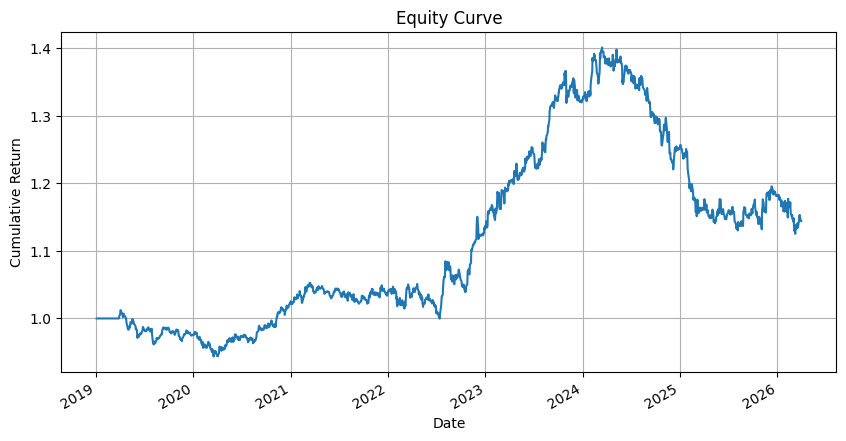

In [59]:
plt.figure(figsize=(10,5))
cum_returns.plot()
plt.title("Equity Curve")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()

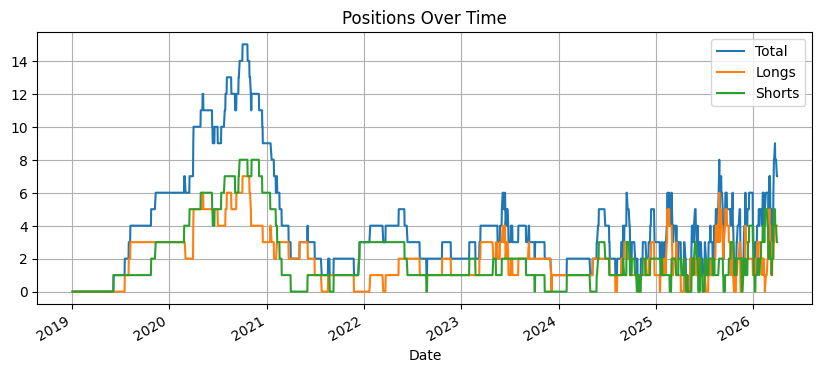

In [53]:
plt.figure(figsize=(10,4))
active_count_series.plot(label="Total")
long_count_series.plot(label="Longs")
short_count_series.plot(label="Shorts")
plt.legend()
plt.title("Positions Over Time")
plt.grid(True)
plt.show()